1. Імпортуємо бібліотеки

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor



2. Налаштовуємо відображення:

In [17]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("Практична робота №1: Множинна лінійна регресія")
print("=" * 60)

Практична робота №1: Множинна лінійна регресія


3. Завантажуємо та оглядаємо данні: виводимо перші 5 рядків:

In [18]:
df = pd.read_csv('Student_Performance.csv')

print("=" * 80)
print("ЗАВАНТАЖЕННЯ ТА ОГЛЯД ДАНИХ")
print("=" * 80)
print("\nПерші 5 рядків датасету:")
print(df.head())
print("\n" + "=" * 80)

ЗАВАНТАЖЕННЯ ТА ОГЛЯД ДАНИХ

Перші 5 рядків датасету:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  Sample Question Papers Practiced  Performance Index
0              7               99                        Yes            9                                 1               91.0
1              4               82                         No            4                                 2               65.0
2              8               51                        Yes            7                                 2               45.0
3              5               52                        Yes            5                                 2               36.0
4              7               75                         No            8                                 5               66.0



4. Перевіривіряємо загальну інформацію про дані:

In [19]:
print("РОЗВІДКОВИЙ АНАЛІЗ ДАНИХ (EDA)")
print("=" * 80)

print("\nІнформація про датасет:")
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} стовпців")
print(f"\nНазви стовпців:\n{list(df.columns)}")
print("\nТипи даних:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

РОЗВІДКОВИЙ АНАЛІЗ ДАНИХ (EDA)

Інформація про датасет:
Розмір датасету: 10000 рядків, 6 стовпців

Назви стовпців:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

Типи даних:
  Hours Studied: int64
  Previous Scores: int64
  Extracurricular Activities: object
  Sleep Hours: int64
  Sample Question Papers Practiced: int64
  Performance Index: float64


5. Переглянемо статистичні характеристики:

In [20]:
print("\nСтатистичний опис:")
desc = df.describe()
print(desc.to_string())


Статистичний опис:
       Hours Studied  Previous Scores   Sleep Hours  Sample Question Papers Practiced  Performance Index
count   10000.000000     10000.000000  10000.000000                      10000.000000       10000.000000
mean        4.992900        69.445700      6.530600                          4.583300          55.224800
std         2.589309        17.343152      1.695863                          2.867348          19.212558
min         1.000000        40.000000      4.000000                          0.000000          10.000000
25%         3.000000        54.000000      5.000000                          2.000000          40.000000
50%         5.000000        69.000000      7.000000                          5.000000          55.000000
75%         7.000000        85.000000      8.000000                          7.000000          71.000000
max         9.000000        99.000000      9.000000                          9.000000         100.000000


6. Перевіримо наявність пропущених значень: 

In [21]:
print("\nПеревірка на пропущені значення:")
missing = df.isnull().sum()
for col, count in missing.items():
    print(f"  {col}: {count}")
print(f"\nЗагальна кількість пропущених значень: {missing.sum()}")


Перевірка на пропущені значення:
  Hours Studied: 0
  Previous Scores: 0
  Extracurricular Activities: 0
  Sleep Hours: 0
  Sample Question Papers Practiced: 0
  Performance Index: 0

Загальна кількість пропущених значень: 0


7. Створюємо теплову карту кореляцій для числових змінних:

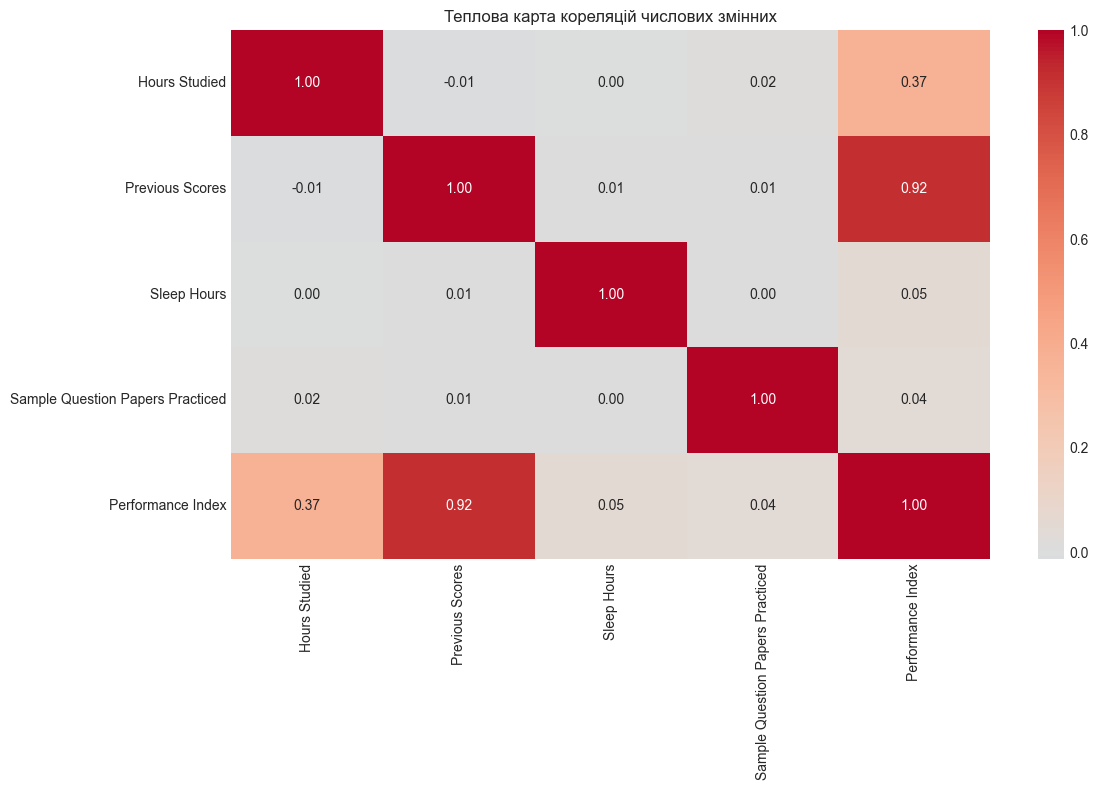


Кореляція з цільовою змінною Performance Index:
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64


In [22]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Теплова карта кореляцій числових змінних')
plt.tight_layout()
plt.show()

print("\nКореляція з цільовою змінною Performance Index:")
print(correlation_matrix['Performance Index'].sort_values(ascending=False))


8. Реалізовуємо обробку категоріальних змінних. Для цього проводимо перевірку унікальних значень категоріальних стовпців. Далі кодуємо бінарні змінні, якщо є інші категоріальні змінні, використовуємо One-Hot Encoding:

In [24]:
print("\n" + "=" * 80)
print("ОБРОБКА КАТЕГОРІАЛЬНИХ ЗМІННИХ")
print("=" * 80)

# Перевірка унікальних значень категоріальних стовпців
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nКатегоріальні стовпці: {list(categorical_cols)}")

for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

# Кодування бінарних змінних
if 'Extracurricular Activities' in df.columns:
    df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'No': 0, 'Yes': 1})

# Якщо є інші категоріальні змінні, використовуємо One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nСтовпці після кодування:")
print(df_encoded.columns.tolist())


ОБРОБКА КАТЕГОРІАЛЬНИХ ЗМІННИХ

Категоріальні стовпці: []

Стовпці після кодування:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


9. Реалізовуємо вибір ознак та цільової змінної:

In [ ]:
print("\n" + "=" * 80)
print("ВИБІР ОЗНАК ТА ЦІЛЬОВОЇ ЗМІННОЇ")
print("=" * 80)

# Цільова змінна
y = df_encoded['Performance Index'].values

# Ознаки (все, крім цільової змінної)
X = df_encoded.drop('Performance Index', axis=1).values

print(f"\nРозмір X (ознаки): {X.shape}")
print(f"Розмір y (цільова змінна): {y.shape}")
print(f"Назви ознак: {df_encoded.drop('Performance Index', axis=1).columns.tolist()}")



ВИБІР ОЗНАК ТА ЦІЛЬОВОЇ ЗМІННОЇ

Розмір X (ознаки): (10000, 5)
Розмір y (цільова змінна): (10000,)
Назви ознак: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']


Додаємо перевірку дисперсії стовпців перед стандартизацією:

In [36]:
print("\nПеревірка дисперсії стовпців (для виявлення константних ознак):")
feature_names = df_encoded.drop('Performance Index', axis=1).columns

for i, col_name in enumerate(feature_names):
    col_std = X[:, i].std()
    col_unique = len(np.unique(X[:, i]))
    print(f"  {col_name}: std={col_std:.4f}, унікальних значень={col_unique}")
    
    if col_std == 0 or col_std < 0.001:
        print(f"    ⚠️ ПРОБЛЕМА: Стовпець має нульову/дуже малу дисперсію!")

# Видалення стовпців з нульовою дисперсією
print("\nВидалення стовпців з нульовою дисперсією...")
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.001)
X_filtered = selector.fit_transform(X)

removed_features = len(feature_names) - X_filtered.shape[1]
if removed_features > 0:
    print(f"Видалено {removed_features} стовпців")
    kept_indices = selector.get_support()
    kept_features = feature_names[kept_indices]
    print(f"Залишились ознаки: {list(kept_features)}")
    X = X_filtered
else:
    print("Всі стовпці мають достатню дисперсію")


Перевірка дисперсії стовпців (для виявлення константних ознак):
  Hours Studied: std=2.5892, унікальних значень=9
  Previous Scores: std=17.3423, унікальних значень=60
  Extracurricular Activities: std=nan, унікальних значень=1
  Sleep Hours: std=1.6958, унікальних значень=6
  Sample Question Papers Practiced: std=2.8672, унікальних значень=10

Видалення стовпців з нульовою дисперсією...
Видалено 1 стовпців
Залишились ознаки: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']


c:\Users\Юлія\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


10. Далі реалізовуємо поділ на навчальну та тестову вибірки:

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nРозмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")


Розмір навчальної вибірки: (8000, 4)
Розмір тестової вибірки: (2000, 4)


11. Реалізовуємо стандартизацію:

In [39]:
print("\n" + "=" * 80)
print("СТАНДАРТИЗАЦІЯ ДАНИХ")
print("=" * 80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Додаємо стовпчик одиниць для intercept β₀
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"\nРозмір X_train_final (з intercept): {X_train_final.shape}")
print(f"Розмір X_test_final (з intercept): {X_test_final.shape}")



СТАНДАРТИЗАЦІЯ ДАНИХ

Розмір X_train_final (з intercept): (8000, 5)
Розмір X_test_final (з intercept): (2000, 5)


12. Реалізовуємо метод градієнтного спуску із нуля. Для цього спочатку ініціалізуємо параметри та гіперпараметри, а потім описуємо функцію для обчислення втрат:

In [40]:
print("\n" + "=" * 80)
print("ГРАДІЄНТНИЙ СПУСК")
print("=" * 80)

# Ініціалізація параметрів
b = np.zeros(X_train_final.shape[1])
print(f"\nІніціалізовані параметри β: {b.shape}")

# Гіперпараметри
epochs = 1000
learning_rate = 0.01

print(f"Кількість ітерацій (epochs): {epochs}")
print(f"Швидкість навчання (learning rate): {learning_rate}")

print("\nПеревірка даних перед навчанням:")
print(f"X_train_final має NaN: {np.isnan(X_train_final).any()}")
print(f"X_train_final має Inf: {np.isinf(X_train_final).any()}")
print(f"y_train має NaN: {np.isnan(y_train).any()}")
print(f"y_train має Inf: {np.isinf(y_train).any()}")
print(f"Розмір X_train_final: {X_train_final.shape}")
print(f"Розмір y_train: {y_train.shape}")

# Функція для обчислення функції втрат (MSE)
def compute_cost(X, y, b):
    """
    Обчислює середню квадратичну помилку (MSE)
    
    Параметри:
    X - матриця ознак (n x m)
    y - вектор цільових значень (n,)
    b - вектор параметрів (m,)
    
    Повертає:
    mse - середня квадратична помилка
    """
    predictions = X.dot(b)
    errors = predictions - y
    mse = (1 / len(y)) * np.sum(errors ** 2)
    return mse



ГРАДІЄНТНИЙ СПУСК

Ініціалізовані параметри β: (5,)
Кількість ітерацій (epochs): 1000
Швидкість навчання (learning rate): 0.01

Перевірка даних перед навчанням:
X_train_final має NaN: False
X_train_final має Inf: False
y_train має NaN: False
y_train має Inf: False
Розмір X_train_final: (8000, 5)
Розмір y_train: (8000,)


13. Реалізовуємо саму функцію градієнтного спуску та навчаємо модель. В кінці виводимо результати:


Початок навчання...
Ітерація 100/1000, MSE: 64.6636
Ітерація 200/1000, MSE: 5.3286
Ітерація 300/1000, MSE: 4.2811
Ітерація 400/1000, MSE: 4.2626
Ітерація 500/1000, MSE: 4.2623
Ітерація 600/1000, MSE: 4.2623
Ітерація 700/1000, MSE: 4.2623
Ітерація 800/1000, MSE: 4.2623
Ітерація 900/1000, MSE: 4.2623
Ітерація 1000/1000, MSE: 4.2623

Навчання завершено!
Фінальні параметри β:
[55.31149991  7.40240352 17.63809529  0.80387754  0.54854089]


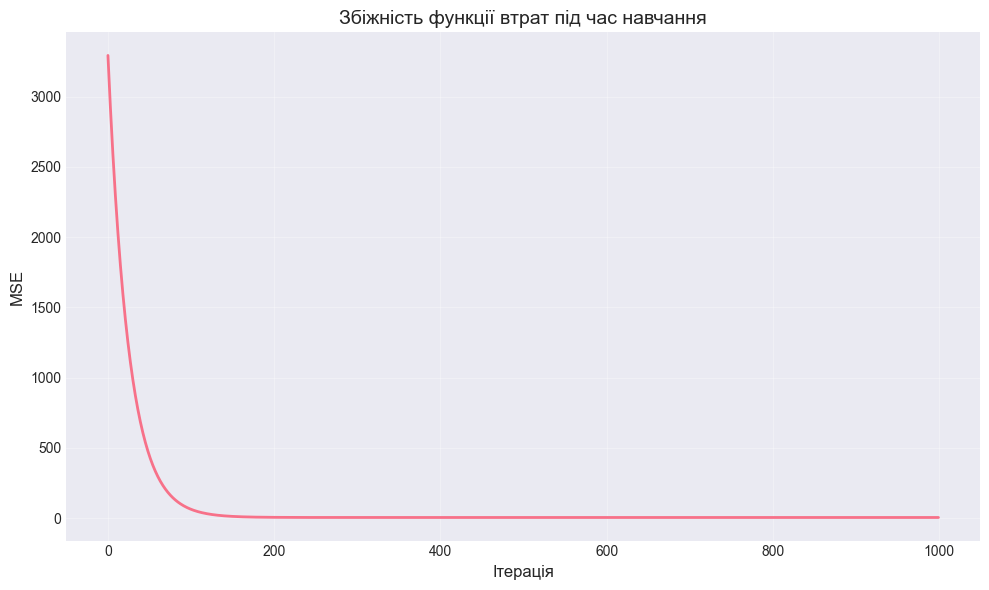

In [ ]:
def gradient_descent(X, y, b, learning_rate, epochs):
    """
    Виконує градієнтний спуск для знаходження оптимальних параметрів
    
    Параметри:
    X - матриця ознак
    y - вектор цільових значень
    b - початковий вектор параметрів
    learning_rate - швидкість навчання
    epochs - кількість ітерацій
    
    Повертає:
    b - оптимізовані параметри
    cost_history - історія значень функції втрат
    """
    cost_history = []  # Для відстеження змін MSE
    m = len(y)
    b = b.copy()
    
    for epoch in range(epochs):
        # Обчислення передбачень
        predictions = X.dot(b)
        
        # Перевірка на nan/inf після передбачень
        if np.isnan(predictions).any() or np.isinf(predictions).any():
            print(f"ПОМИЛКА на ітерації {epoch}: predictions містить nan/inf")
            print(f"b на цій ітерації: {b}")
            break
        
        # Обчислення помилки
        errors = predictions - y
        
        # Обчислення градієнта (похідна MSE за b)
        # Градієнт = (2/m) * X^T * (predictions - y)
        gradient = (2 / m) * X.T.dot(errors)
        
        # Перевірка градієнта
        if np.isnan(gradient).any() or np.isinf(gradient).any():
            print(f"ПОМИЛКА на ітерації {epoch}: gradient містить nan/inf")
            break
        
        # Оновлення ваг
        b = b - learning_rate * gradient
        
        # Збереження поточного MSE для історії
        cost = compute_cost(X, y, b)
        cost_history.append(cost)
        
        # Виведення прогресу кожні 100 ітерацій
        if (epoch + 1) % 100 == 0:
            print(f"Ітерація {epoch + 1}/{epochs}, MSE: {cost:.4f}")
    
    return b, cost_history

# 2.5 Навчання моделі
print("\nПочаток навчання...")
b_final, cost_history = gradient_descent(
    X_train_final, y_train, b, learning_rate, epochs
)

print(f"\nНавчання завершено!")
print(f"Фінальні параметри β:\n{b_final}")

# 2.6 Візуалізація навчання
plt.figure(figsize=(10, 6))
plt.plot(cost_history, linewidth=2)
plt.xlabel('Ітерація', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Збіжність функції втрат під час навчання', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

14. Реалізовуємо оцінку якості моделі на тестових даних:

In [43]:
print("\n" + "=" * 80)
print("ОЦІНКА ЯКОСТІ МОДЕЛІ")
print("=" * 80)

#Прогнозування
y_pred = X_test_final.dot(b_final)

#Розрахунок метрик
mse_test = np.mean((y_test - y_pred) ** 2)
r2 = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"\nМетрики на тестовій вибірці:")
print(f"MSE (Mean Squared Error): {mse_test:.4f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mse_test):.4f}")
print(f"R² Score: {r2:.4f}")

#Порівняння з бейзлайном
baseline_pred = np.full_like(y_test, np.mean(y_train))
baseline_mse = np.mean((y_test - baseline_pred) ** 2)

print(f"\nБейзлайн (передбачення середнього значення):")
print(f"Baseline MSE: {baseline_mse:.4f}")
print(f"Покращення: {((baseline_mse - mse_test) / baseline_mse * 100):.2f}%")




ОЦІНКА ЯКОСТІ МОДЕЛІ

Метрики на тестовій вибірці:
MSE (Mean Squared Error): 4.1823
RMSE (Root Mean Squared Error): 2.0451
R² Score: 0.9887

Бейзлайн (передбачення середнього значення):
Baseline MSE: 370.7730
Покращення: 98.87%


15. Реалізовуємо перевірку класичної лінійної регресії(6 припущень). Спочатку перше припущення - лінійність зв'язку:


ПЕРЕВІРКА ПРИПУЩЕНЬ КЛАСИЧНОЇ ЛІНІЙНОЇ РЕГРЕСІЇ

1. ЛІНІЙНІСТЬ ЗВ'ЯЗКУ
----------------------------------------


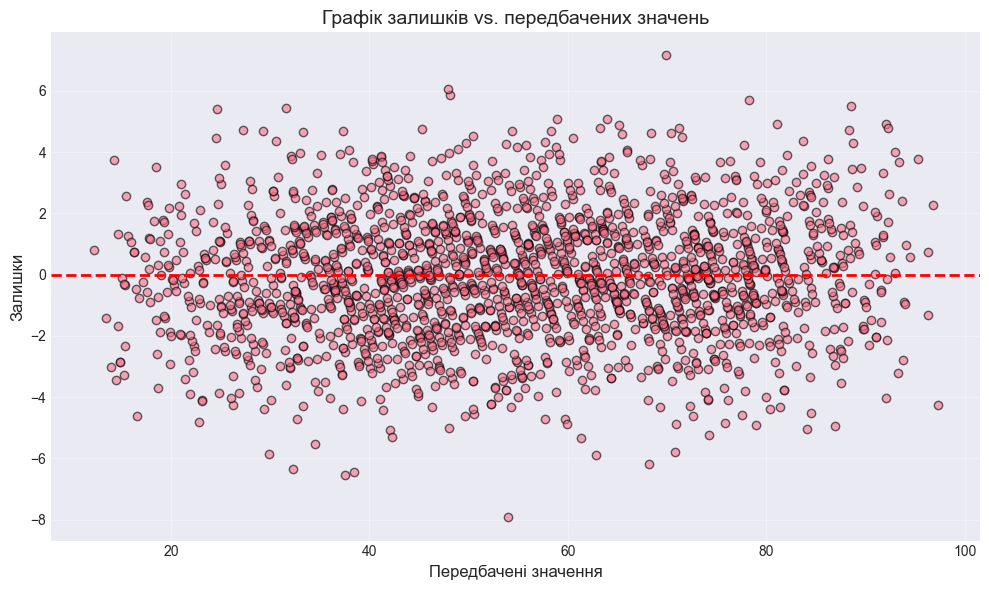

Аналіз: Якщо залишки випадково розкидані навколо нуля без систематичного
паттерну, припущення лінійності виконується.


In [44]:
print("\n" + "=" * 80)
print("ПЕРЕВІРКА ПРИПУЩЕНЬ КЛАСИЧНОЇ ЛІНІЙНОЇ РЕГРЕСІЇ")
print("=" * 80)

residuals = y_test - y_pred

#ПРИПУЩЕННЯ 1: Лінійність зв'язку
print("\n1. ЛІНІЙНІСТЬ ЗВ'ЯЗКУ")
print("-" * 40)

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Передбачені значення', fontsize=12)
plt.ylabel('Залишки', fontsize=12)
plt.title('Графік залишків vs. передбачених значень', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Аналіз: Якщо залишки випадково розкидані навколо нуля без систематичного")
print("паттерну, припущення лінійності виконується.")


16. Далі реалізовуємо припущення 2 - відсутність мультиколінеарності:

In [55]:
#ПРИПУЩЕННЯ 2: Відсутність мультиколінеарності
print("\n2. ВІДСУТНІСТЬ МУЛЬТИКОЛІНЕАРНОСТІ (VIF)")
print("-" * 40)

# Отримуємо назви ознак, які ЗАЛИШИЛИСЬ після фільтрації
# Використовуємо kept_features з попереднього кроку
vif_data = pd.DataFrame()
vif_data["Ознака"] = kept_features 
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled, i) 
                   for i in range(X_train_scaled.shape[1])]

print("\nЗначення VIF для кожної ознаки:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\nУВАГА: Ознаки з високим VIF (>5):")
    print(high_vif.to_string(index=False))
else:
    print("\nВсі VIF < 5: мультиколінеарність відсутня")


2. ВІДСУТНІСТЬ МУЛЬТИКОЛІНЕАРНОСТІ (VIF)
----------------------------------------

Значення VIF для кожної ознаки:
                          Ознака      VIF
                   Hours Studied 1.000375
                 Previous Scores 1.000236
                     Sleep Hours 1.000052
Sample Question Papers Practiced 1.000319

Всі VIF < 5: мультиколінеарність відсутня


17. Далі наступне припущення - нормальність залишків: 


3. НОРМАЛЬНІСТЬ ЗАЛИШКІВ
----------------------------------------


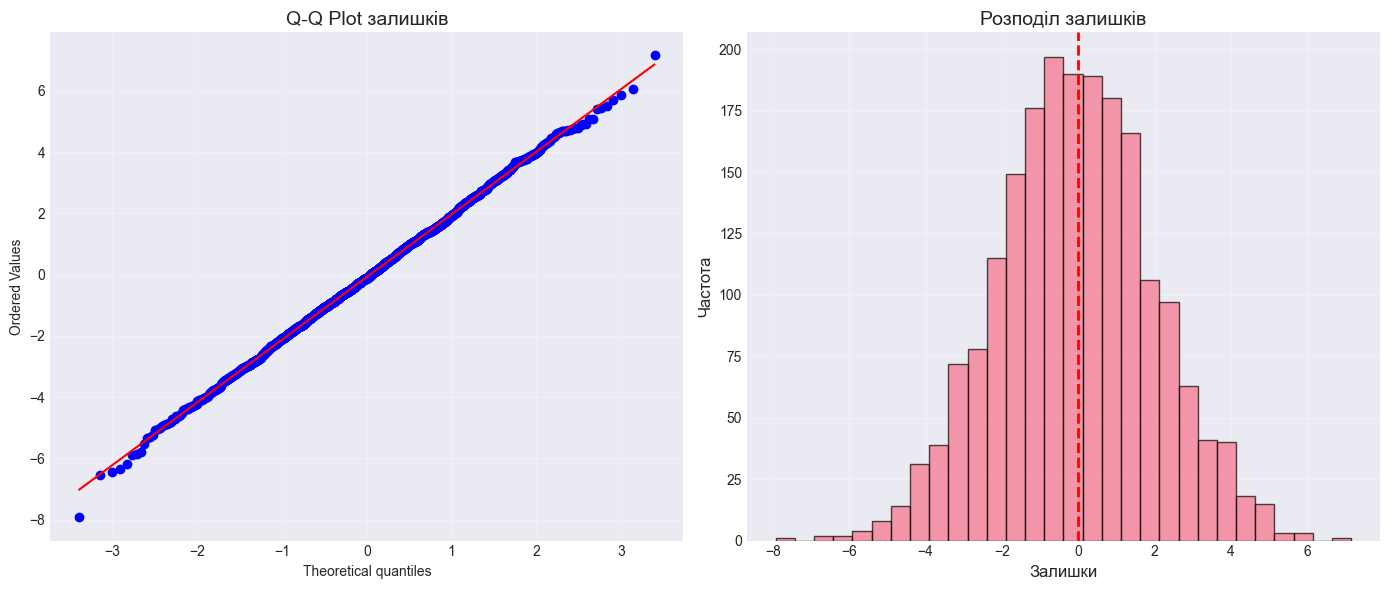


Тест Шапіро-Вілка:
Статистика: 0.9996
P-value: 0.9761
P-value > 0.05: залишки мають нормальний розподіл


In [56]:
#ПРИПУЩЕННЯ 3: Нормальність залишків
print("\n3. НОРМАЛЬНІСТЬ ЗАЛИШКІВ")
print("-" * 40)

# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot залишків', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Гістограма залишків
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Залишки', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title('Розподіл залишків', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Тест Шапіро-Вілка
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nТест Шапіро-Вілка:")
print(f"Статистика: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("P-value > 0.05: залишки мають нормальний розподіл")
else:
    print("P-value < 0.05: залишки НЕ мають нормальний розподіл")

18. Потім припущення про гомоскедастичність (постійна дисперсія):


4. ГОМОСКЕДАСТИЧНІСТЬ (ПОСТІЙНА ДИСПЕРСІЯ)
----------------------------------------


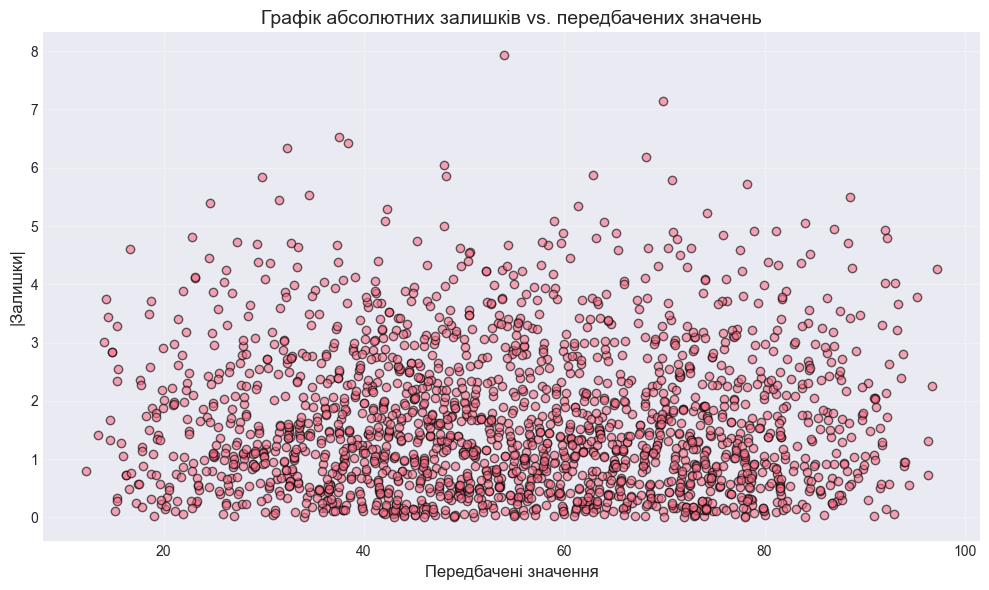

Аналіз: Якщо хмара точок має приблизно однакову ширину по всій довжині,
дисперсія залишків постійна (гомоскедастичність).
Якщо хмара нагадує 'воронку', присутня гетероскедастичність.


In [48]:
#ПРИПУЩЕННЯ 4: Гомоскедастичність (постійна дисперсія)
print("\n4. ГОМОСКЕДАСТИЧНІСТЬ (ПОСТІЙНА ДИСПЕРСІЯ)")
print("-" * 40)

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, np.abs(residuals), alpha=0.6, edgecolors='k')
plt.xlabel('Передбачені значення', fontsize=12)
plt.ylabel('|Залишки|', fontsize=12)
plt.title('Графік абсолютних залишків vs. передбачених значень', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Аналіз: Якщо хмара точок має приблизно однакову ширину по всій довжині,")
print("дисперсія залишків постійна (гомоскедастичність).")
print("Якщо хмара нагадує 'воронку', присутня гетероскедастичність.")

19. Далі передостаннє припущення - відсутність автокореляції:

In [50]:
#ПРИПУЩЕННЯ 5: Відсутність автокореляції
print("\n5. ВІДСУТНІСТЬ АВТОКОРЕЛЯЦІЇ")
print("-" * 40)

dw_stat = durbin_watson(residuals)
print(f"\nТест Дарбіна-Вотсона: {dw_stat:.4f}")
print("Інтерпретація:")
print("  - Значення близьке до 2.0: автокореляція відсутня")
print("  - Значення < 1.5: позитивна автокореляція")
print("  - Значення > 2.5: негативна автокореляція")

if 1.5 < dw_stat < 2.5:
    print("Автокореляція відсутня")
else:
    print("Присутня автокореляція")



5. ВІДСУТНІСТЬ АВТОКОРЕЛЯЦІЇ
----------------------------------------

Тест Дарбіна-Вотсона: 2.0498
Інтерпретація:
  - Значення близьке до 2.0: автокореляція відсутня
  - Значення < 1.5: позитивна автокореляція
  - Значення > 2.5: негативна автокореляція
Автокореляція відсутня


20. І останнє - відсутність викидів та впливових спостережень: 


6. ВІДСУТНІСТЬ ВИКИДІВ ТА ВПЛИВОВИХ СПОСТЕРЕЖЕНЬ
----------------------------------------


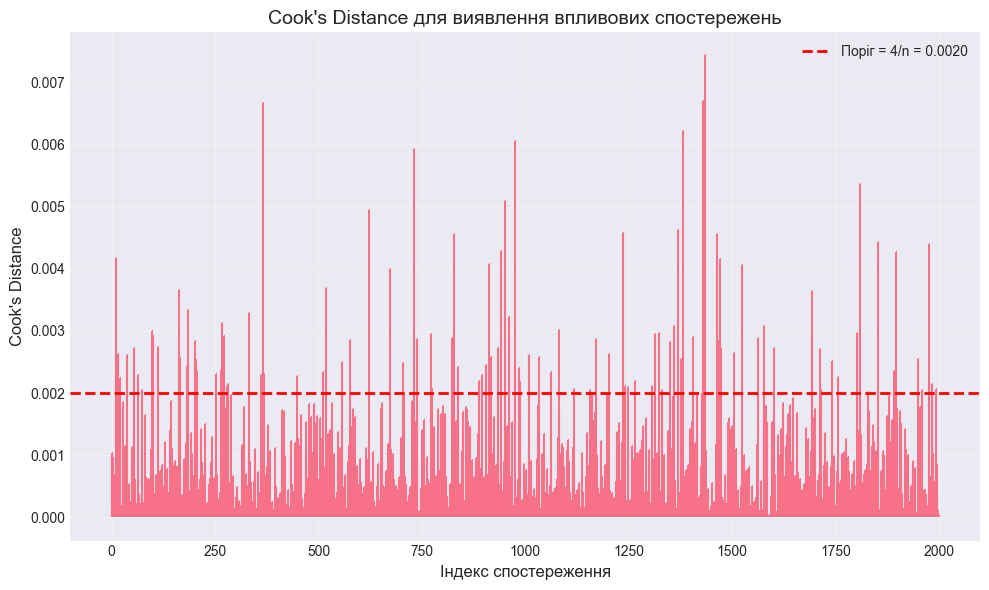


Поріг Cook's Distance: 0.0020
Кількість впливових спостережень: 111
Індекси впливових спостережень: [11 15 16 19 36 53 54 64 73 98]
Присутні впливові спостереження

Кількість викидів (|z-score| > 3): 5
Індекси викидів: [ 976 1429 1434 1810 1975]
Присутні викиди


In [53]:
#ПРИПУЩЕННЯ 6: Відсутність викидів та впливових спостережень
print("\n6. ВІДСУТНІСТЬ ВИКИДІВ ТА ВПЛИВОВИХ СПОСТЕРЕЖЕНЬ")
print("-" * 40)

# Cook's Distance
def cooks_distance(X, residuals):
    """Обчислює Cook's Distance для кожного спостереження"""
    n = len(residuals)
    p = X.shape[1]
    
    # Матриця шапки (hat matrix)
    H = X.dot(np.linalg.inv(X.T.dot(X))).dot(X.T)
    leverage = np.diag(H)
    
    # MSE
    mse = np.sum(residuals ** 2) / (n - p)
    
    # Cook's Distance
    cooks_d = (residuals ** 2 / (p * mse)) * (leverage / (1 - leverage) ** 2)
    
    return cooks_d

cooks_d = cooks_distance(X_test_final, residuals)
threshold = 4 / len(y_test)

plt.figure(figsize=(10, 6))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=',', basefmt=" ")
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, 
            label=f'Поріг = 4/n = {threshold:.4f}')
plt.xlabel('Індекс спостереження', fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)
plt.title("Cook's Distance для виявлення впливових спостережень", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

influential = np.where(cooks_d > threshold)[0]
print(f"\nПоріг Cook's Distance: {threshold:.4f}")
print(f"Кількість впливових спостережень: {len(influential)}")

if len(influential) > 0:
    print(f"Індекси впливових спостережень: {influential[:10]}")  # Показуємо перші 10
    print("Присутні впливові спостереження")
else:
    print("Впливові спостереження відсутні")

# Викиди (великі залишки)
z_scores = np.abs(stats.zscore(residuals))
outliers = np.where(z_scores > 3)[0]

print(f"\nКількість викидів (|z-score| > 3): {len(outliers)}")
if len(outliers) > 0:
    print(f"Індекси викидів: {outliers[:10]}")  # Показуємо перші 10
    print("Присутні викиди")
else:
    print("Викиди відсутні")

21. Робимо фінальний звіт:

In [54]:
print("\n" + "=" * 80)
print("ФІНАЛЬНИЙ ЗВІТ")
print("=" * 80)

print("\nРЕЗУЛЬТАТИ МОДЕЛІ:")
print(f"  • MSE на тестовій вибірці: {mse_test:.4f}")
print(f"  • RMSE на тестовій вибірці: {np.sqrt(mse_test):.4f}")
print(f"  • R² Score: {r2:.4f}")
print(f"  • Покращення над бейзлайном: {((baseline_mse - mse_test) / baseline_mse * 100):.2f}%")

print("\nПЕРЕВІРКА ПРИПУЩЕНЬ:")
print("  1. Лінійність: Перевірте графік залишків")
print(f"  2. Мультиколінеарність: {len(vif_data[vif_data['VIF'] > 5])} ознак з VIF > 5")
print(f"  3. Нормальність: Shapiro-Wilk p-value = {shapiro_p:.4f}")
print(f"  4. Гомоскедастичність: Перевірте графік абсолютних залишків")
print(f"  5. Автокореляція: Durbin-Watson = {dw_stat:.4f}")
print(f"  6. Викиди та впливові: {len(outliers)} викидів, {len(influential)} впливових")

print("\nВИСНОВОК:")
print("Модель множинної лінійної регресії успішно навчена методом градієнтного спуску.")
print(f"Модель пояснює {r2*100:.2f}% варіації в даних (R² = {r2:.4f}).")
print("Детальний аналіз припущень дозволяє оцінити надійність моделі.")
print("\n" + "=" * 80)


ФІНАЛЬНИЙ ЗВІТ

РЕЗУЛЬТАТИ МОДЕЛІ:
  • MSE на тестовій вибірці: 4.1823
  • RMSE на тестовій вибірці: 2.0451
  • R² Score: 0.9887
  • Покращення над бейзлайном: 98.87%

ПЕРЕВІРКА ПРИПУЩЕНЬ:
  1. Лінійність: Перевірте графік залишків
  2. Мультиколінеарність: 0 ознак з VIF > 5
  3. Нормальність: Shapiro-Wilk p-value = 0.9761
  4. Гомоскедастичність: Перевірте графік абсолютних залишків
  5. Автокореляція: Durbin-Watson = 2.0498
  6. Викиди та впливові: 5 викидів, 111 впливових

ВИСНОВОК:
Модель множинної лінійної регресії успішно навчена методом градієнтного спуску.
Модель пояснює 98.87% варіації в даних (R² = 0.9887).
Детальний аналіз припущень дозволяє оцінити надійність моделі.

